In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import modelWithPersonas as mod
from utils import *

In [2]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

Current working directory: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\notebooks
Path to experiment files: ../results/experiments/
c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments


In [3]:
openai.__version__

'1.50.2'

In [4]:
# set simulation parameters

seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_steps = 50
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

# Positive feedback

## High-Volatility Setup

In [ ]:
# High-volatility setup 
n_agents = 4
personas = ["Aggressive Speculator", "Momentum Trader", "Momentum Trader", "Aggressive Speculator"]

In [6]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 0.


In [7]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp, personas=personas)

Experiment Fingerprints: e49da607c4f5b2b0d9716ed92e067fc6
 
 Time: 0, agent: 0, persona: Aggressive Speculator 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Aggressive speculator aiming to maximize profit by predicting bold price movements. Betting on continuing major trends for a longer duration than anticipated.",\n  "predictedValue": 40.25\n}'}
 
 Time: 0, agent: 1, persona: Momentum Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "As an initial prediction without historical data, I would suggest starting at a moderate level reflecting potential market equilibrium.",\n    "predictedValue": 50\n}'}
 
 Time: 0, agent: 2, persona: Momentum Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "

Text(0.5, 0, 'Time step')

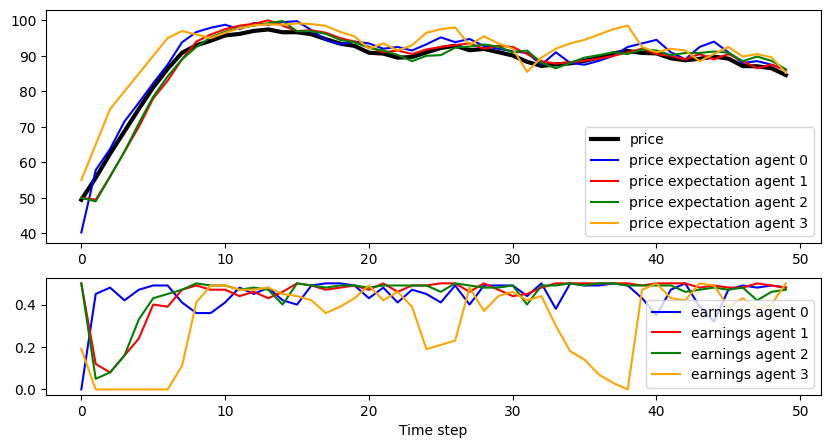

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [ ]:
batch_folder = create_batch_folder("High-volatility")
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    print(f"Running experiment {i} for High-volatility Setup...")

    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=batch_folder, personas=personas)

Created batch experiment folder: ../results/experiments/experiment_batch_20250226_121541_High-volatility
Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Running experiment 1 for High-volatility Setup...
Experiment Fingerprints: e49da607c4f5b2b0d9716ed92e067fc6
 
 Time: 0, agent: 0, persona: Aggressive Speculator 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Following an aggressive strategy, I will predict a high market price to capitalize

## Stability-Focused Setup

In [10]:
n_agents = 4
personas = ["Contrarian Investor", "Fundamentalist Trader", "Fundamentalist Trader", "Contrarian Investor"]

In [11]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 0.


In [12]:
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp, personas=personas)

Experiment Fingerprints: e49da607c4f5b2b0d9716ed92e067fc6
 
 Time: 0, agent: 0, persona: Contrarian Investor 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I am starting with a neutral prediction close to the initial price, based on the absence of recent market trends.",\n  "predictedValue": 50\n}'}
 
 Time: 0, agent: 1, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Initial prediction based on stability and historical averages.",\n  "predictedValue": 50.00\n}  '}
 
 Time: 0, agent: 2, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "My initial prediction is based on market stability and historical averages. I opt for a moderate 

Text(0.5, 0, 'Time step')

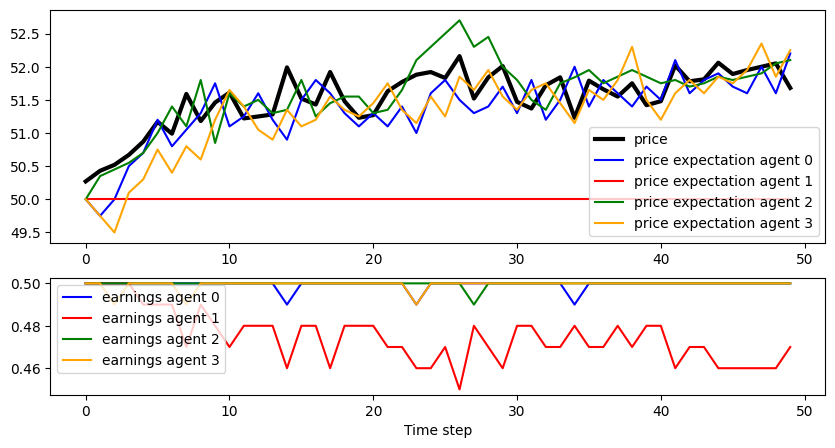

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [14]:
batch_folder = create_batch_folder("Stability-Focused")
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    print(f"Running experiment {i} for Stability-Focused Setup...")

    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=batch_folder, personas=personas)

Created batch experiment folder: ../results/experiments/experiment_batch_20250226_130928_Stability-Focused
Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_4_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Running experiment 1 for Stability-Focused Setup...
Experiment Fingerprints: e49da607c4f5b2b0d9716ed92e067fc6
 
 Time: 0, agent: 0, persona: Contrarian Investor 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Anticipating a potential overshoot of the initial price, I predict a slightly lo

## Realistic, Diverse market Scenario

In [15]:
n_agents = 6
personas = ["Aggressive Speculator", "Momentum Investor", "Balanced-Decision Maker", "Market Analyst", "Contrarian Investor", "Fundamentalist Trader"]

In [16]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_6_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_6_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 0.


In [17]:
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp, personas=personas)

Experiment Fingerprints: 45a66fe60bf989a7b9338ea978894815
 
 Time: 0, agent: 0, persona: Aggressive Speculator 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Following an aggressive strategy, I predict a significant price increase in the next period.",\n  "predictedValue": 40.00\n}'}
 
 Time: 0, agent: 1, persona: Momentum Investor 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will make an initial conservative prediction based on the current stability of the market.",\n  "predictedValue": 55.00\n}'}
 
 Time: 0, agent: 2, persona: Balanced-Decision Maker 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n"reasoning": "Assuming a stable market at the start, I predict a neutral price close to the initial pri

Text(0.5, 0, 'Time step')

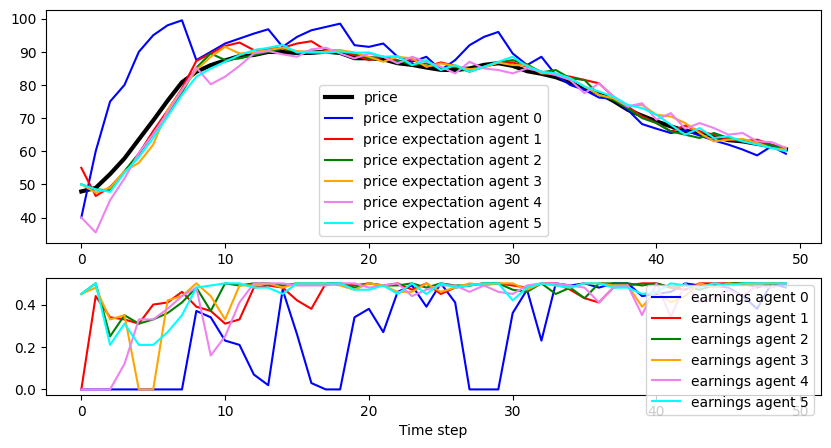

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [19]:
batch_folder = create_batch_folder("Realistic")
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    print(f"Running experiment {i} for Realistic, Diverse Setup...")

    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=batch_folder, personas=personas)

Created batch experiment folder: ../results/experiments/experiment_batch_20250226_143324_Realistic
Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_6_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_6_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Running experiment 1 for Realistic, Diverse Setup...
Experiment Fingerprints: 45a66fe60bf989a7b9338ea978894815
 
 Time: 0, agent: 0, persona: Aggressive Speculator 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Following an aggressive strategy, I anticipate a strong upward trend in the market pr

# Negative feedback

In [ ]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import modelWithPersonas as mod
from utils import *

In [ ]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

In [ ]:
# set simulation parameters
# disabling seed in this case
# isolate personality from seeding
#seed = 0
#np.random.seed(seed)
seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 50
#n_steps = 5
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

In [ ]:
expmnt_num = 1
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

In [ ]:
# list of personas to test
# persona_types = [
#     "Aggressive Speculator",
#     "Momentum Trader",
#     "Balanced Decision-Maker",
#     "Market Analyst",
#     "Contrarian Investor",
#     "Fundamentalist Trader"
# ]

persona_types = [
    "Momentum Trader"
]

In [ ]:
for persona in persona_types:
    batch_folder = create_batch_folder(persona)
    print(f"\nRunning experiments for persona: {persona}")

    for i in range(1, 11):
        expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
        print(f"Running experiment {i} for {persona}...")
        
        p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=batch_folder, persona_type=persona)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_on,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_on[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_on[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend(bbox_to_anchor=(1.35, 0.7))
axes[1].legend(bbox_to_anchor=(1.28, 1))

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [ ]:
a = mod.create_experiment_folder()